# Lab 01: Initial Analysis Questions 1-8
## Keshav Bhakta

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

<div class="alert alert-block alert-warning">
<b>1:</b>  Load the Foreign Gifts data
</div>


In [2]:
df = pd.read_csv('./lab_1/ForeignGifts_edu.csv')
df.head(3)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce


<div class="alert alert-block alert-warning">
<b>2:</b>  Describe the differences between different classes of gift types
</div>


In [3]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

<b>There are three different classes of gifts in the Gift Type column. 
1. Contract
2. Monetary Gift
3. Real Estate 

Contracts seem to be when the country and college are given work for compensation. A Monetary gift could be something like a donation. Real Estate could be a gift of land on that countries soil.<b>

<div class="alert alert-block alert-warning">
<b>3:</b>  Answer the following questions:
</div>


<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>

In [4]:
money_totals = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
money_totals.sort_values(ascending=False).head(3)

Country of Giftor
QATAR      2706240869
ENGLAND    1464906771
CHINA      1237952112
Name: Foreign Gift Amount, dtype: int64

<b>Qatar gives the most money in total.<b>

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [5]:
df['Country of Giftor'].value_counts().head(3)

Country of Giftor
ENGLAND    3655
CHINA      2461
CANADA     2344
Name: count, dtype: int64

<b>England initiates the most gifts by count.<b>

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [6]:
avg_gift = df.groupby('Country of Giftor')['Foreign Gift Amount'].mean()
avg_gift.sort_values(ascending=False).head(3)

Country of Giftor
BERMUDA   7688837.37
ECUADOR   3985140.29
QATAR     3905109.48
Name: Foreign Gift Amount, dtype: float64

<b>Bermuda gives the largest gifts on average<b>

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

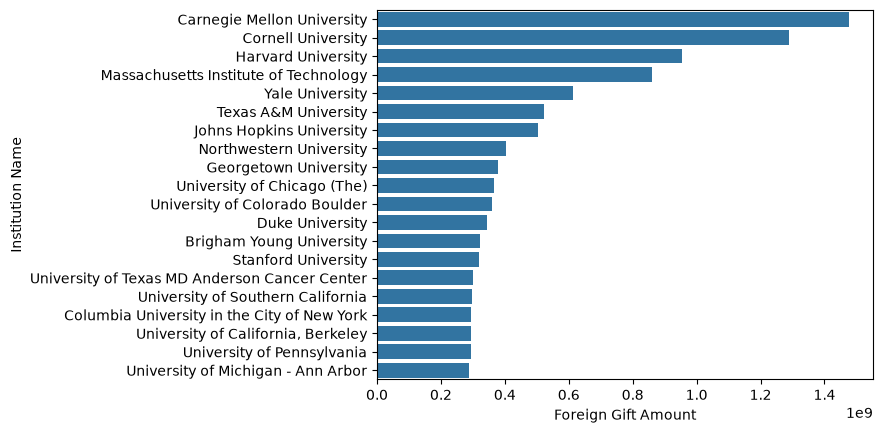

In [7]:

institution_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
institution_totals = institution_totals.sort_values(ascending=False).head(20).reset_index()
institution_totals

sns.barplot(data=institution_totals, x='Foreign Gift Amount', y='Institution Name')
plt.show()


In [9]:
institution_totals.head()

,Institution Name,Foreign Gift Amount
0,Carnegie Mellon University,1477922504
1,Cornell University,1289937761
2,Harvard University,954803610
3,Massachusetts Institute of Technology,859071692
4,Yale University,613441311


<b>Carnegie Mellon University receives the most money in total.<b>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

In [ ]:
df['Institution Name'].value_counts().head(3)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Name: count, dtype: int64

<b>University of California, Los Angeles receives the greatest number of gifts by count.<b>

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

In [ ]:
sum_institution = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
avg_institution = sum_institution.mean()
med_institution = sum_institution.median()

print(avg_institution)
print(med_institution)

52202878.974842764
6486791.5


<b> The Mean is $52,202,878.97 and the Median is $6,486,791.50. The numbers are vastly different and could be that way as there could be extremely high donation numbers which bring the average up. <b>

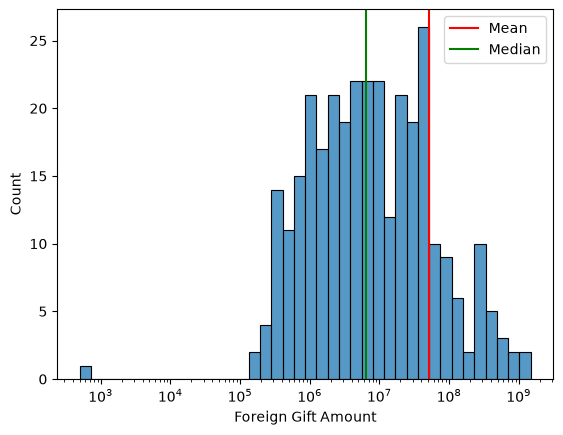

In [ ]:
sns.histplot(sum_institution, bins=40, log_scale=True)

plt.axvline(avg_institution, color='red', label='Mean')
plt.axvline(med_institution, color='green', label='Median')
plt.legend()
plt.show()

<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

In [ ]:
flow = pd.crosstab(
    index = df['Country of Giftor'],
    columns = df['Institution Name'],
    values = df['Foreign Gift Amount'],
    aggfunc='sum'
)

flow.stack().sort_values(ascending=False).head(3)

Country of Giftor  Institution Name          
QATAR              Cornell University           1018473315.00
BERMUDA            Carnegie Mellon University    750000000.00
QATAR              Texas A&M University          504099350.00
dtype: float64

<b> The largest flow from a single country to a single institution comes from Qatar to Cornell University <b>

<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>

In [ ]:
flow2 = pd.crosstab(
    index = df['Giftor Name'],
    columns = df['Institution Name'], 
    values = df['Foreign Gift Amount'],
    aggfunc='sum'
)

flow2.stack().sort_values(ascending=False).head(5)

Giftor Name                          Institution Name          
Qatar Foundation/Qatar National Res  Cornell University           796197000.00
Qatar Foundation                     Texas A&M University         465638397.00
Qatar Foundation for Education       Carnegie Mellon University   373914113.00
Qatar Foundation                     Georgetown University        314161323.00
                                     Northwestern University      305556268.00
dtype: float64

<b> The top 3 giftors are:
1. Qatar Foundation/Qatar National Res -> Cornell University
2. Qatar Foundation -> Texas A&M University
3. Qatar Foudation for Education -> Carnegie Mellon University <b>

<div class="alert alert-block alert-warning">
<b>Bonus:</b>  Plot the flows from giftors to institutions. 
</div>

In [ ]:
import plotly.graph_objects as go


giftor = 'Giftor Name'
#giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()